In [173]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

# Find the project root that contains the src folder
current = Path.cwd().resolve()

for p in [current] + list(current.parents):
    if (p / "src").exists():
        repo_root = p
        break
else:
    raise FileNotFoundError("Could not find a folder containing 'src'.")

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

print("Current working directory:", current)
print("Added repo root:", repo_root)
print("src exists:", (repo_root / "src").exists())

from pathlib import Path
import numpy as np
import pandas as pd

import src.utils.pdata_io as pdio
from src.proc.extract_epoch_windows import load_epoch_windows

data_root, pdata_root, cc_data = pdio.load_project_context()

windows_df = load_epoch_windows(
    pdata_root=pdata_root,
    filename="behavior_epoch_windows.h5",
    key="windows/prepost_1s"
)

valid_windows = windows_df[windows_df["valid_window"]].copy()

print("All windows:", windows_df.shape)
print("Valid windows:", valid_windows.shape)

valid_windows.groupby(["phase", "epoch_name"]).size().reset_index(name="n_windows")

encoder_epoch_df = pd.read_hdf(
    Path(pdata_root) / "_cache" / "behavior_epoch_metrics.h5",
    key="encoder/prepost_1s_speedThresh_1cms"
)

from src.qc.qc_events import load_behavior_qc_tables

events_df, session_summary_df, _ = load_behavior_qc_tables(
    pdata_root=pdata_root,
    filename="behavior_QC.h5"
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Current working directory: /home/nmldata2/ccaw/Python/notebooks
Added repo root: /home/nmldata2/ccaw/Python
src exists: True
[LOADED] Project context: /mnt/pdata/Classical_Conditioning/_cache/project_context.pkl
[LOADED] Epoch windows: /mnt/pdata/Classical_Conditioning/_cache/behavior_epoch_windows.h5
[KEY] windows/prepost_1s
All windows: (103980, 29)
Valid windows: (83023, 29)
[LOADED] Behavior QC tables: /mnt/pdata/Classical_Conditioning/_cache/behavior_QC.h5


In [2]:
%connect_info

{"key":"8fc4457c-4483-4ec3-b55c-b08e900f0984","signature_scheme":"hmac-sha256","transport":"tcp","ip":"127.0.0.1","hb_port":9000,"control_port":9001,"shell_port":9002,"stdin_port":9003,"iopub_port":9004,"kernel_name":"python3820jvsc74a57bd07f6243129cfff82ede3c5c59589229000c07b9cd1160ea9b86b0dd361ed08050"}

Paste the above JSON into a file, and connect with:
    $> jupyter <app> --existing <file>
or, if you are local, you can connect with just:
    $> jupyter <app> --existing /run/user/1000/jupyter/runtime/kernel-v365c51bbedcb8a1eb99d32767840a52be41f02e01.json
or even just:
    $> jupyter <app> --existing
if this is the most recent Jupyter kernel you have started.


In [174]:
# from src.proc.behavior_metrics import add_normalized_phase_day

# encoder_epoch_df = add_normalized_phase_day(encoder_epoch_df)
encoder_epoch_df.head()

,animal,date,phase,event_number,anchor_name,anchor_type,anchor_time_s,window_position,window_s,epoch_name,...,net_direction_bias,frac_stationary,frac_moving,frac_forward,frac_backward,frac_low_net_movement,dominant_locomotor_state,phase_session_number,n_sessions_in_phase,normalized_phase_day
0,NML_04,2026_01_12,air_training,1,air_off_mid,middle,31.5222,post,1.0,air_off_mid_post_1s,...,0.680638,0.0808,0.9192,0.6118,0.3074,0.0,forward,1.0,15.0,0.0
1,NML_04,2026_01_12,air_training,1,air_off_mid,middle,31.5222,pre,1.0,air_off_mid_pre_1s,...,0.755565,0.3230,0.6770,0.4804,0.1966,0.0,forward,1.0,15.0,0.0
2,NML_04,2026_01_12,air_training,1,air_off,main,23.9790,post,1.0,air_off_post_1s,...,1.000000,0.0000,1.0000,1.0000,0.0000,0.0,forward,1.0,15.0,0.0
3,NML_04,2026_01_12,air_training,1,air_off,main,23.9790,pre,1.0,air_off_pre_1s,...,0.951624,0.0340,0.9660,0.8530,0.1130,0.0,forward,1.0,15.0,0.0
4,NML_04,2026_01_12,air_training,1,air_on,main,19.9564,post,1.0,air_on_post_1s,...,-0.487133,0.5560,0.4440,0.0924,0.3516,0.0,stationary,1.0,15.0,0.0


In [29]:
from src.utils.pdata_organize import make_session_availability_summary

session_availability_df = make_session_availability_summary(
    events_df=events_df,
    windows_df=windows_df,
    min_session_duration_s=900,
    min_valid_events=3,
)

In [27]:
session_availability_df.sort_values(
    ["phase", "animal", "date"]
)

,animal,date,phase,session_duration_s,n_events_total,n_events_valid,short_recording,enough_valid_events,good_session_basic,nwin_LED_off_post,...,nwin_air_on_mid_pre,nwin_pseudo_tone_off_post,nwin_pseudo_tone_off_pre,nwin_pseudo_tone_on_post,nwin_pseudo_tone_on_pre,nwin_tone_off_post,nwin_tone_off_pre,nwin_tone_on_post,nwin_tone_on_pre,n_valid_windows_total
16,NML_04,2026_01_12,air_training,1308.9,59,57,False,True,True,0,...,16,17,25,57,57,0,0,0,0,488
17,NML_04,2026_01_13,air_training,1307.0,55,53,False,True,True,0,...,14,14,18,53,53,0,0,0,0,418
18,NML_04,2026_01_14,air_training,1506.2,59,57,False,True,True,0,...,27,27,38,57,57,0,0,0,0,565
19,NML_04,2026_01_15,air_training,1319.9,60,58,False,True,True,0,...,8,8,27,58,58,0,0,0,0,513
20,NML_04,2026_01_16,air_training,1354.6,64,62,False,True,True,0,...,1,1,3,62,62,0,0,0,0,408
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
208,NML_08,2026_03_17,tone_air_training,1235.7,48,46,False,True,True,0,...,26,0,0,0,0,26,40,46,46,492
209,NML_08,2026_03_18,tone_air_training,1236.0,51,49,False,True,True,0,...,0,0,0,0,0,0,39,49,49,462
210,NML_08,2026_03_19,tone_air_training,1214.1,50,48,False,True,True,0,...,1,0,0,0,0,1,37,48,48,445
211,NML_08,2026_03_20,tone_air_training,1220.1,48,46,False,True,True,0,...,20,0,0,0,0,20,39,46,46,476


In [30]:
phase_animal_summary = (
    session_availability_df
    .groupby(["phase", "animal"], dropna=False)
    .agg(
        n_sessions=("date", "nunique"),
        n_good_sessions=("good_session_basic", "sum"),
        n_short_sessions=("short_recording", "sum"),
        first_date=("date", "min"),
        last_date=("date", "max"),
    )
    .reset_index()
)

phase_animal_summary

,phase,animal,n_sessions,n_good_sessions,n_short_sessions,first_date,last_date
0,air_training,NML_04,15,15,0,2026_01_12,2026_01_27
1,air_training,NML_05,15,14,0,2026_01_12,2026_01_27
2,air_training,NML_06,15,15,0,2026_01_12,2026_01_27
3,air_training,NML_07,16,16,0,2026_02_21,2026_03_11
4,air_training,NML_08,17,16,1,2026_02_21,2026_03_11
5,habituation,NML_04,16,16,0,2025_12_27,2026_01_11
6,habituation,NML_05,16,16,0,2025_12_27,2026_01_11
7,habituation,NML_06,16,16,0,2025_12_27,2026_01_11
8,habituation,NML_07,19,14,0,2026_02_02,2026_02_20
9,habituation,NML_08,18,15,0,2026_02_02,2026_02_20


In [36]:
from src.utils.pdata_organize import add_day_bins_to_sessions

session_day_df = add_day_bins_to_sessions(
    session_availability_df,
    use_good_sessions_only=True,
)

In [32]:
cols = [
    "phase",
    "animal",
    "date",
    "good_session_basic",
    "session_duration_s",
    "n_events_valid",
    "phase_day_number_good",
    "n_good_sessions_in_phase",
    "normalized_phase_day_good",
    "phase_day_bin",
]

session_day_df[cols].sort_values(
    ["phase", "animal", "date"]
)

,phase,animal,date,good_session_basic,session_duration_s,n_events_valid,phase_day_number_good,n_good_sessions_in_phase,normalized_phase_day_good,phase_day_bin
16,air_training,NML_04,2026_01_12,True,1308.9,57,1.0,15.0,0.000000,early
17,air_training,NML_04,2026_01_13,True,1307.0,53,2.0,15.0,0.071429,early
18,air_training,NML_04,2026_01_14,True,1506.2,57,3.0,15.0,0.142857,early
19,air_training,NML_04,2026_01_15,True,1319.9,58,4.0,15.0,0.214286,early
20,air_training,NML_04,2026_01_16,True,1354.6,62,5.0,15.0,0.285714,early
...,...,...,...,...,...,...,...,...,...,...
208,tone_air_training,NML_08,2026_03_17,True,1235.7,46,6.0,10.0,0.555556,middle
209,tone_air_training,NML_08,2026_03_18,True,1236.0,49,7.0,10.0,0.666667,middle
210,tone_air_training,NML_08,2026_03_19,True,1214.1,48,8.0,10.0,0.777778,late
211,tone_air_training,NML_08,2026_03_20,True,1220.1,46,9.0,10.0,0.888889,late


In [37]:
session_epoch_df = session_epoch_df.merge(
    session_day_df[
        [
            "animal",
            "date",
            "phase",
            "phase_day_number_good",
            "n_good_sessions_in_phase",
            "normalized_phase_day_good",
            "phase_day_bin",
            "good_session_basic",
        ]
    ],
    on=["animal", "date", "phase"],
    how="left"
)



In [38]:
session_epoch_good_df = session_epoch_df[
    session_epoch_df["good_session_basic"] == True
].copy()

In [39]:

from src.utils.pdata_organize import build_validated_epoch_matrix


epoch_matrix_df = build_validated_epoch_matrix(
    encoder_epoch_df=encoder_epoch_df,
    session_day_df=session_day_df,
    keep_good_sessions_only=True,
    keep_valid_windows_only=True,
)

In [40]:
epoch_matrix_df[
    [
        "phase",
        "animal",
        "date",
        "good_session_basic",
        "phase_day_number_good",
        "normalized_phase_day_good",
        "phase_day_bin",
        "session_time_bin",
        "event_number",
        "anchor_name",
        "window_position",
        "epoch_name",
    ]
].head(30)

,phase,animal,date,good_session_basic,phase_day_number_good,normalized_phase_day_good,phase_day_bin,session_time_bin,event_number,anchor_name,window_position,epoch_name
0,air_training,NML_04,2026_01_12,True,1.0,0.0,early,early,1,pseudo_tone_on,post,pseudo_tone_on_post_1s
1,air_training,NML_04,2026_01_12,True,1.0,0.0,early,early,1,pseudo_tone_on,pre,pseudo_tone_on_pre_1s
2,air_training,NML_04,2026_01_12,True,1.0,0.0,early,early,1,air_on,post,air_on_post_1s
3,air_training,NML_04,2026_01_12,True,1.0,0.0,early,early,1,air_on,pre,air_on_pre_1s
4,air_training,NML_04,2026_01_12,True,1.0,0.0,early,early,1,air_off,post,air_off_post_1s
5,air_training,NML_04,2026_01_12,True,1.0,0.0,early,early,1,air_off,pre,air_off_pre_1s
6,air_training,NML_04,2026_01_12,True,1.0,0.0,early,early,1,air_off_mid,post,air_off_mid_post_1s
7,air_training,NML_04,2026_01_12,True,1.0,0.0,early,early,1,air_off_mid,pre,air_off_mid_pre_1s
8,air_training,NML_04,2026_01_12,True,1.0,0.0,early,early,2,pseudo_tone_on,post,pseudo_tone_on_post_1s
9,air_training,NML_04,2026_01_12,True,1.0,0.0,early,early,2,pseudo_tone_on,pre,pseudo_tone_on_pre_1s


In [42]:
epoch_matrix_df.groupby(
    ["phase", "animal", "phase_day_bin"],
    dropna=False
).agg(
    n_dates=("date", "nunique"),
    n_rows=("epoch_name", "count"),
    n_events=("event_number", "nunique"),
).reset_index()

,phase,animal,phase_day_bin,n_dates,n_rows,n_events
0,air_training,NML_04,early,5,2392,62
1,air_training,NML_04,late,5,2582,50
2,air_training,NML_04,middle,5,2470,52
3,air_training,NML_05,early,5,2304,64
4,air_training,NML_05,late,4,448,17
5,air_training,NML_05,middle,5,926,36
6,air_training,NML_06,early,5,2127,55
7,air_training,NML_06,late,5,1663,49
8,air_training,NML_06,middle,5,2618,52
9,air_training,NML_07,early,6,2252,71


In [43]:
from statsmodels.stats.anova import AnovaRM
import pandas as pd
import numpy as np

# --------------------------------------------------
# 1. Select tone-on windows during tone-air training
# --------------------------------------------------

tone_on_df = epoch_matrix_df[
    (epoch_matrix_df["phase"] == "tone_air_training") &
    (epoch_matrix_df["anchor_name"] == "tone_on") &
    (epoch_matrix_df["phase_day_bin"].isin(["early", "middle", "late"])) &
    (epoch_matrix_df["window_position"].isin(["pre", "post"]))
].copy()

# --------------------------------------------------
# 2. Average to animal × day-bin × pre/post level
# --------------------------------------------------
# This averages across sessions, events, and session_time_bin for now.

tone_on_rm_df = (
    tone_on_df
    .groupby(
        ["animal", "phase_day_bin", "window_position"],
        dropna=False
    )
    .agg(
        frac_forward=("frac_forward", "mean"),
        n_windows=("frac_forward", "count"),
        n_events=("event_number", "nunique"),
        n_dates=("date", "nunique"),
    )
    .reset_index()
)

# Optional: enforce categorical order
tone_on_rm_df["phase_day_bin"] = pd.Categorical(
    tone_on_rm_df["phase_day_bin"],
    categories=["early", "middle", "late"],
    ordered=True
)

tone_on_rm_df["window_position"] = pd.Categorical(
    tone_on_rm_df["window_position"],
    categories=["pre", "post"],
    ordered=True
)

tone_on_rm_df

,animal,phase_day_bin,window_position,frac_forward,n_windows,n_events,n_dates
0,NML_04,early,post,0.225380,143,38,4
1,NML_04,early,pre,0.158259,143,38,4
2,NML_04,late,post,0.222479,71,53,3
3,NML_04,late,pre,0.169141,71,53,3
4,NML_04,middle,post,0.233484,76,30,3
5,NML_04,middle,pre,0.120868,76,30,3
6,NML_05,early,post,0.554759,64,23,4
7,NML_05,early,pre,0.324188,64,23,4
8,NML_05,late,post,0.555212,49,20,3
9,NML_05,late,pre,0.308220,49,20,3


In [44]:
cell_check = (
    tone_on_rm_df
    .groupby("animal")
    .size()
    .reset_index(name="n_cells")
)

cell_check

,animal,n_cells
0,NML_04,6
1,NML_05,6
2,NML_06,6
3,NML_07,6
4,NML_08,6


In [46]:
aov = AnovaRM(
    data=tone_on_rm_df,
    depvar="frac_forward",
    subject="animal",
    within=["phase_day_bin", "window_position"]
).fit()

print(aov)

tone_on_rm_df.groupby(["phase_day_bin", "window_position"])["frac_forward"].mean()

                          Anova
                              F Value Num DF Den DF Pr > F
----------------------------------------------------------
phase_day_bin                  0.9454 2.0000 8.0000 0.4280
window_position               16.9333 1.0000 4.0000 0.0147
phase_day_bin:window_position  0.1975 2.0000 8.0000 0.8246



phase_day_bin  window_position
early          pre                0.165872
               post               0.299246
middle         pre                0.185638
               post               0.303817
late           pre                0.149128
               post               0.269313
Name: frac_forward, dtype: float64

In [47]:
from statsmodels.stats.anova import AnovaRM
import pandas as pd

# --------------------------------------------------
# Tone-on speed analysis
# phase = tone_air_training
# anchor = tone_on
# outcome = mean_speed_path_cms
# --------------------------------------------------

tone_on_speed_df = epoch_matrix_df[
    (epoch_matrix_df["phase"] == "tone_air_training") &
    (epoch_matrix_df["anchor_name"] == "tone_on") &
    (epoch_matrix_df["phase_day_bin"].isin(["early", "middle", "late"])) &
    (epoch_matrix_df["window_position"].isin(["pre", "post"]))
].copy()

# Average to animal × day-bin × pre/post level
tone_on_speed_rm_df = (
    tone_on_speed_df
    .groupby(
        ["animal", "phase_day_bin", "window_position"],
        dropna=False
    )
    .agg(
        mean_speed_path_cms=("mean_speed_path_cms", "mean"),
        n_windows=("mean_speed_path_cms", "count"),
        n_events=("event_number", "nunique"),
        n_dates=("date", "nunique"),
    )
    .reset_index()
)

tone_on_speed_rm_df["phase_day_bin"] = pd.Categorical(
    tone_on_speed_rm_df["phase_day_bin"],
    categories=["early", "middle", "late"],
    ordered=True
)

tone_on_speed_rm_df["window_position"] = pd.Categorical(
    tone_on_speed_rm_df["window_position"],
    categories=["pre", "post"],
    ordered=True
)

# Check cells
cell_check_speed = (
    tone_on_speed_rm_df
    .groupby("animal")
    .size()
    .reset_index(name="n_cells")
)

cell_check_speed

,animal,n_cells
0,NML_04,6
1,NML_05,6
2,NML_06,6
3,NML_07,6
4,NML_08,6


In [48]:
aov_speed = AnovaRM(
    data=tone_on_speed_rm_df,
    depvar="mean_speed_path_cms",
    subject="animal",
    within=["phase_day_bin", "window_position"]
).fit()

print(aov_speed)

                          Anova
                              F Value Num DF Den DF Pr > F
----------------------------------------------------------
phase_day_bin                  1.8306 2.0000 8.0000 0.2215
window_position                9.7565 1.0000 4.0000 0.0354
phase_day_bin:window_position  0.0474 2.0000 8.0000 0.9540



In [49]:
speed_means = (
    tone_on_speed_rm_df
    .groupby(["phase_day_bin", "window_position"], observed=False)
    .agg(
        mean_speed=("mean_speed_path_cms", "mean"),
        sem_speed=("mean_speed_path_cms", lambda x: x.std(ddof=1) / (len(x) ** 0.5)),
        n_animals=("animal", "nunique"),
    )
    .reset_index()
)

speed_means

,phase_day_bin,window_position,mean_speed,sem_speed,n_animals
0,early,pre,0.601394,0.207809,5
1,early,post,0.873768,0.268174,5
2,middle,pre,0.686888,0.254414,5
3,middle,post,0.941554,0.302323,5
4,late,pre,0.470968,0.144546,5
5,late,post,0.747228,0.240752,5


In [50]:
from statsmodels.stats.anova import AnovaRM
import pandas as pd
import numpy as np

# --------------------------------------------------
# 1. Select early-day tone-on windows during tone-air training
# --------------------------------------------------

early_tone_on_df = epoch_matrix_df[
    (epoch_matrix_df["phase"] == "tone_air_training") &
    (epoch_matrix_df["anchor_name"] == "tone_on") &
    (epoch_matrix_df["phase_day_bin"] == "early") &
    (epoch_matrix_df["session_time_bin"].isin(["early", "middle", "late"])) &
    (epoch_matrix_df["window_position"].isin(["pre", "post"]))
].copy()

# --------------------------------------------------
# 2. Average to animal × session-time-bin × pre/post level
# --------------------------------------------------
# This averages across early tone-air training days and events.

early_tone_session_rm_df = (
    early_tone_on_df
    .groupby(
        ["animal", "session_time_bin", "window_position"],
        dropna=False
    )
    .agg(
        frac_forward=("frac_forward", "mean"),
        mean_speed_path_cms=("mean_speed_path_cms", "mean"),
        frac_stationary=("frac_stationary", "mean"),
        n_windows=("frac_forward", "count"),
        n_events=("event_number", "nunique"),
        n_dates=("date", "nunique"),
    )
    .reset_index()
)

# Set factor order
early_tone_session_rm_df["session_time_bin"] = pd.Categorical(
    early_tone_session_rm_df["session_time_bin"],
    categories=["early", "middle", "late"],
    ordered=True
)

early_tone_session_rm_df["window_position"] = pd.Categorical(
    early_tone_session_rm_df["window_position"],
    categories=["pre", "post"],
    ordered=True
)

early_tone_session_rm_df

,animal,session_time_bin,window_position,frac_forward,mean_speed_path_cms,frac_stationary,n_windows,n_events,n_dates
0,NML_04,early,post,0.211933,0.551718,0.673626,54,14,4
1,NML_04,early,pre,0.174881,0.428158,0.766404,54,14,4
2,NML_04,late,post,0.238140,0.591821,0.690260,40,15,4
3,NML_04,late,pre,0.129530,0.323046,0.846670,40,15,4
4,NML_04,middle,post,0.229784,0.644077,0.640494,49,15,4
5,NML_04,middle,pre,0.163392,0.426595,0.801073,49,15,4
6,NML_05,early,post,0.578100,2.416851,0.376436,28,8,4
7,NML_05,early,pre,0.501900,2.292298,0.495129,28,8,4
8,NML_05,late,post,0.482783,1.310178,0.410683,12,11,4
9,NML_05,late,pre,0.226233,0.726768,0.773767,12,11,4


In [51]:
cell_check = (
    early_tone_session_rm_df
    .groupby("animal")
    .size()
    .reset_index(name="n_cells")
)

cell_check

,animal,n_cells
0,NML_04,6
1,NML_05,6
2,NML_06,6
3,NML_07,6
4,NML_08,6


In [52]:
aov_early_session = AnovaRM(
    data=early_tone_session_rm_df,
    depvar="frac_forward",
    subject="animal",
    within=["session_time_bin", "window_position"]
).fit()

print(aov_early_session)

                            Anova
                                 F Value Num DF Den DF Pr > F
-------------------------------------------------------------
session_time_bin                  0.7253 2.0000 8.0000 0.5135
window_position                  14.5187 1.0000 4.0000 0.0189
session_time_bin:window_position  1.4955 2.0000 8.0000 0.2807



In [53]:
from statsmodels.stats.anova import AnovaRM
import pandas as pd
import numpy as np

# --------------------------------------------------
# Air-training pseudo-tone-on analysis
# --------------------------------------------------

pseudo_air_df = epoch_matrix_df[
    (epoch_matrix_df["phase"] == "air_training") &
    (epoch_matrix_df["anchor_name"] == "pseudo_tone_on") &
    (epoch_matrix_df["phase_day_bin"].isin(["early", "middle", "late"])) &
    (epoch_matrix_df["window_position"].isin(["pre", "post"]))
].copy()

pseudo_air_rm_df = (
    pseudo_air_df
    .groupby(
        ["animal", "phase_day_bin", "window_position"],
        dropna=False
    )
    .agg(
        frac_forward=("frac_forward", "mean"),
        mean_speed_path_cms=("mean_speed_path_cms", "mean"),
        n_windows=("frac_forward", "count"),
        n_events=("event_number", "nunique"),
        n_dates=("date", "nunique"),
    )
    .reset_index()
)

pseudo_air_rm_df["phase_day_bin"] = pd.Categorical(
    pseudo_air_rm_df["phase_day_bin"],
    categories=["early", "middle", "late"],
    ordered=True
)

pseudo_air_rm_df["window_position"] = pd.Categorical(
    pseudo_air_rm_df["window_position"],
    categories=["pre", "post"],
    ordered=True
)

# Check completeness
pseudo_air_rm_df.groupby("animal").size().reset_index(name="n_cells")

,animal,n_cells
0,NML_04,6
1,NML_05,6
2,NML_06,6
3,NML_07,6
4,NML_08,6


In [54]:
aov_pseudo_frac_forward = AnovaRM(
    data=pseudo_air_rm_df,
    depvar="frac_forward",
    subject="animal",
    within=["phase_day_bin", "window_position"]
).fit()

print(aov_pseudo_frac_forward)

                          Anova
                              F Value Num DF Den DF Pr > F
----------------------------------------------------------
phase_day_bin                  0.7239 2.0000 8.0000 0.5141
window_position                0.5752 1.0000 4.0000 0.4904
phase_day_bin:window_position  0.3279 2.0000 8.0000 0.7296



In [55]:
pseudo_air_rm_df.groupby(
    ["phase_day_bin", "window_position"],
    observed=False
).agg(
    mean_frac_forward=("frac_forward", "mean"),
    sem_frac_forward=("frac_forward", lambda x: x.std(ddof=1) / np.sqrt(len(x))),
    mean_speed=("mean_speed_path_cms", "mean"),
    sem_speed=("mean_speed_path_cms", lambda x: x.std(ddof=1) / np.sqrt(len(x))),
    n_animals=("animal", "nunique"),
).reset_index()

,phase_day_bin,window_position,mean_frac_forward,sem_frac_forward,mean_speed,sem_speed,n_animals
0,early,pre,0.387420,0.095481,2.428595,1.002029,5
1,early,post,0.372687,0.094441,2.365683,1.051615,5
2,middle,pre,0.299711,0.067573,1.199170,0.409206,5
3,middle,post,0.291126,0.058678,1.147272,0.323917,5
4,late,pre,0.244695,0.084106,0.760129,0.269364,5
5,late,post,0.236136,0.093629,0.795234,0.351782,5


In [56]:
# --------------------------------------------------
# Compare real tone_on in tone-air training
# vs pseudo_tone_on in air training
# --------------------------------------------------

real_tone_df = epoch_matrix_df[
    (epoch_matrix_df["phase"] == "tone_air_training") &
    (epoch_matrix_df["anchor_name"] == "tone_on") &
    (epoch_matrix_df["window_position"].isin(["pre", "post"]))
].copy()

real_tone_df["cue_condition"] = "real_tone"

pseudo_tone_df = epoch_matrix_df[
    (epoch_matrix_df["phase"] == "air_training") &
    (epoch_matrix_df["anchor_name"] == "pseudo_tone_on") &
    (epoch_matrix_df["window_position"].isin(["pre", "post"]))
].copy()

pseudo_tone_df["cue_condition"] = "pseudo_tone"

cue_compare_df = pd.concat(
    [real_tone_df, pseudo_tone_df],
    ignore_index=True
)

cue_compare_rm_df = (
    cue_compare_df
    .groupby(
        ["animal", "cue_condition", "window_position"],
        dropna=False
    )
    .agg(
        frac_forward=("frac_forward", "mean"),
        mean_speed_path_cms=("mean_speed_path_cms", "mean"),
        n_windows=("frac_forward", "count"),
        n_events=("event_number", "nunique"),
        n_dates=("date", "nunique"),
    )
    .reset_index()
)

cue_compare_rm_df["cue_condition"] = pd.Categorical(
    cue_compare_rm_df["cue_condition"],
    categories=["pseudo_tone", "real_tone"],
    ordered=True
)

cue_compare_rm_df["window_position"] = pd.Categorical(
    cue_compare_rm_df["window_position"],
    categories=["pre", "post"],
    ordered=True
)

cue_compare_rm_df.groupby("animal").size().reset_index(name="n_cells")

,animal,n_cells
0,NML_04,4
1,NML_05,4
2,NML_06,4
3,NML_07,4
4,NML_08,4


In [57]:
aov_cue_compare_frac_forward = AnovaRM(
    data=cue_compare_rm_df,
    depvar="frac_forward",
    subject="animal",
    within=["cue_condition", "window_position"]
).fit()

print(aov_cue_compare_frac_forward)

                          Anova
                              F Value Num DF Den DF Pr > F
----------------------------------------------------------
cue_condition                  1.7630 1.0000 4.0000 0.2550
window_position                8.3635 1.0000 4.0000 0.0445
cue_condition:window_position 31.1113 1.0000 4.0000 0.0051



In [58]:
aov_cue_compare_speed = AnovaRM(
    data=cue_compare_rm_df,
    depvar="mean_speed_path_cms",
    subject="animal",
    within=["cue_condition", "window_position"]
).fit()

print(aov_cue_compare_speed)

                          Anova
                              F Value Num DF Den DF Pr > F
----------------------------------------------------------
cue_condition                  3.5943 1.0000 4.0000 0.1309
window_position                2.4598 1.0000 4.0000 0.1919
cue_condition:window_position 12.8520 1.0000 4.0000 0.0231



In [59]:
cue_delta_df = (
    cue_compare_rm_df
    .pivot_table(
        index=["animal", "cue_condition"],
        columns="window_position",
        values=["frac_forward", "mean_speed_path_cms"],
        aggfunc="mean"
    )
)

cue_delta_df.columns = [
    f"{metric}_{pos}"
    for metric, pos in cue_delta_df.columns
]

cue_delta_df = cue_delta_df.reset_index()

cue_delta_df["delta_frac_forward"] = (
    cue_delta_df["frac_forward_post"] -
    cue_delta_df["frac_forward_pre"]
)

cue_delta_df["delta_mean_speed_path_cms"] = (
    cue_delta_df["mean_speed_path_cms_post"] -
    cue_delta_df["mean_speed_path_cms_pre"]
)

cue_delta_df

,animal,cue_condition,frac_forward_pre,frac_forward_post,mean_speed_path_cms_pre,mean_speed_path_cms_post,delta_frac_forward,delta_mean_speed_path_cms
0,NML_04,pseudo_tone,0.396011,0.333575,1.937229,1.569452,-0.062437,-0.367777
1,NML_04,real_tone,0.151124,0.226794,0.452361,0.596434,0.075670,0.144073
2,NML_05,pseudo_tone,0.356930,0.371275,1.410379,1.523960,0.014345,0.113581
3,NML_05,real_tone,0.356924,0.571634,1.342538,1.868714,0.214710,0.526176
4,NML_06,pseudo_tone,0.163726,0.163241,0.546759,0.521952,-0.000485,-0.024807
5,NML_06,real_tone,0.082188,0.263194,0.310966,0.730579,0.181006,0.419614
6,NML_07,pseudo_tone,0.382995,0.391793,2.865242,2.980164,0.008798,0.114923
7,NML_07,real_tone,0.184456,0.265359,0.609716,0.776750,0.080904,0.167034
8,NML_08,pseudo_tone,0.241349,0.224475,1.071719,1.019306,-0.016875,-0.052413
9,NML_08,real_tone,0.064020,0.140756,0.230866,0.343530,0.076736,0.112665


In [60]:
cue_delta_df.groupby("cue_condition").agg(
    mean_delta_frac_forward=("delta_frac_forward", "mean"),
    sem_delta_frac_forward=("delta_frac_forward", lambda x: x.std(ddof=1) / np.sqrt(len(x))),
    mean_delta_speed=("delta_mean_speed_path_cms", "mean"),
    sem_delta_speed=("delta_mean_speed_path_cms", lambda x: x.std(ddof=1) / np.sqrt(len(x))),
    n_animals=("animal", "nunique"),
).reset_index()

,cue_condition,mean_delta_frac_forward,sem_delta_frac_forward,mean_delta_speed,sem_delta_speed,n_animals
0,pseudo_tone,-0.011331,0.013829,-0.043299,0.088135,5
1,real_tone,0.125805,0.029907,0.273912,0.083411,5


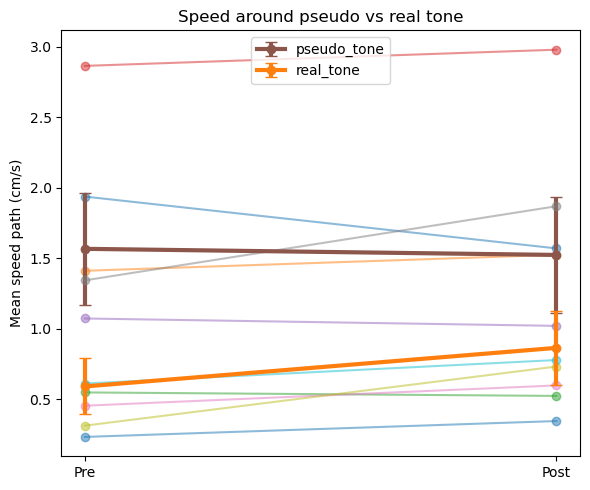

In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Make sure categorical order is correct
plot_df = cue_compare_rm_df.copy()

plot_df["cue_condition"] = pd.Categorical(
    plot_df["cue_condition"],
    categories=["pseudo_tone", "real_tone"],
    ordered=True
)

plot_df["window_position"] = pd.Categorical(
    plot_df["window_position"],
    categories=["pre", "post"],
    ordered=True
)

# Mean ± SEM across animals
summary = (
    plot_df
    .groupby(["cue_condition", "window_position"], observed=False)
    .agg(
        mean_speed=("mean_speed_path_cms", "mean"),
        sem_speed=("mean_speed_path_cms", lambda x: x.std(ddof=1) / np.sqrt(len(x))),
    )
    .reset_index()
)

fig, ax = plt.subplots(figsize=(6, 5))

x_map = {"pre": 0, "post": 1}

for cue in ["pseudo_tone", "real_tone"]:
    sub = plot_df[plot_df["cue_condition"] == cue]

    # plot each animal
    for animal, a_sub in sub.groupby("animal"):
        a_sub = a_sub.sort_values("window_position")
        xs = [x_map[w] for w in a_sub["window_position"]]
        ys = a_sub["mean_speed_path_cms"].values
        ax.plot(xs, ys, marker="o", alpha=0.5)

    # plot group mean ± sem
    s = summary[summary["cue_condition"] == cue].sort_values("window_position")
    xs = [x_map[w] for w in s["window_position"]]
    ys = s["mean_speed"].values
    yerr = s["sem_speed"].values
    ax.errorbar(xs, ys, yerr=yerr, marker="o", linewidth=3, capsize=4, label=cue)

ax.set_xticks([0, 1])
ax.set_xticklabels(["Pre", "Post"])
ax.set_ylabel("Mean speed path (cm/s)")
ax.set_title("Speed around pseudo vs real tone")
ax.legend()
plt.tight_layout()
plt.show()

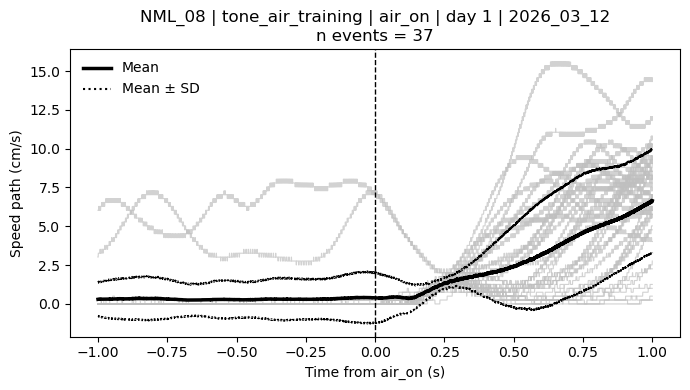

In [151]:
from src.vis.plots import plot_raw_speed_traces_around_anchor

pseudo_result = plot_raw_speed_traces_around_anchor(
    epoch_matrix_df=epoch_matrix_df,
    animal="NML_08",
    phase="tone_air_training",
    anchor_name="air_on",
    phase_day_number_good=1,
    speed_key="speed_path_cms",
    pre_s=1.0,
    post_s=1.0,
)

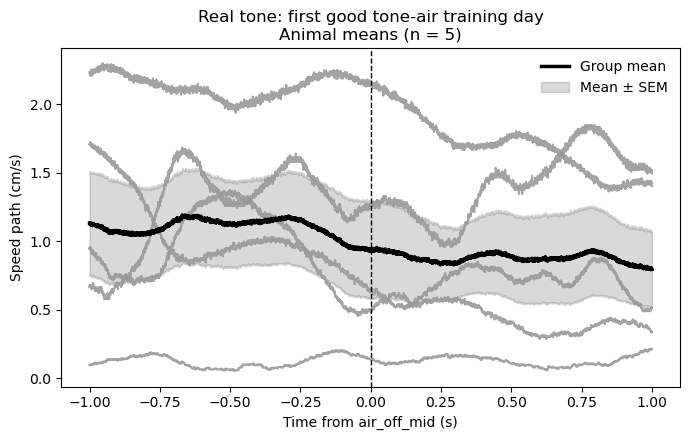

In [159]:

from src.vis.plots import plot_group_animal_mean_traces


animals = ["NML_04", "NML_05", "NML_06", "NML_07", "NML_08"]

real_group_plot = plot_group_animal_mean_traces(
    epoch_matrix_df=epoch_matrix_df,
    animals=animals,
    phase="tone_air_training",
    anchor_name="air_off_mid",
    phase_day_number_good=1,
    speed_key="speed_path_cms",
    pre_s=1.0,
    post_s=1.0,
    title="Real tone: first good tone-air training day",
    use_shaded_sem=True,
)

In [161]:
from statsmodels.stats.anova import AnovaRM
import pandas as pd
import numpy as np

# --------------------------------------------------
# 1. Select habituation LED_on / LED_off windows
# --------------------------------------------------

hab_led_df = epoch_matrix_df[
    (epoch_matrix_df["phase"] == "habituation") &
    (epoch_matrix_df["anchor_name"].isin(["LED_on", "LED_off"])) &
    (epoch_matrix_df["window_position"].isin(["pre", "post"])) &
    (epoch_matrix_df["session_time_bin"].isin(["early", "middle", "late"])) &
    (epoch_matrix_df["phase_day_bin"].isin(["early", "middle", "late"]))
].copy()

# --------------------------------------------------
# 2. Average to animal × factor-cell level
# --------------------------------------------------
# This is required for AnovaRM: one row per subject per condition cell.

hab_led_rm_df = (
    hab_led_df
    .groupby(
        [
            "animal",
            "anchor_name",
            "window_position",
            "session_time_bin",
            "phase_day_bin",
        ],
        dropna=False
    )
    .agg(
        frac_forward=("frac_forward", "mean"),
        mean_speed_path_cms=("mean_speed_path_cms", "mean"),
        frac_stationary=("frac_stationary", "mean"),
        n_windows=("frac_forward", "count"),
        n_events=("event_number", "nunique"),
        n_dates=("date", "nunique"),
    )
    .reset_index()
)

# --------------------------------------------------
# 3. Set factor orders
# --------------------------------------------------

hab_led_rm_df["anchor_name"] = pd.Categorical(
    hab_led_rm_df["anchor_name"],
    categories=["LED_on", "LED_off"],
    ordered=True
)

hab_led_rm_df["window_position"] = pd.Categorical(
    hab_led_rm_df["window_position"],
    categories=["pre", "post"],
    ordered=True
)

hab_led_rm_df["session_time_bin"] = pd.Categorical(
    hab_led_rm_df["session_time_bin"],
    categories=["early", "middle", "late"],
    ordered=True
)

hab_led_rm_df["phase_day_bin"] = pd.Categorical(
    hab_led_rm_df["phase_day_bin"],
    categories=["early", "middle", "late"],
    ordered=True
)

hab_led_rm_df.head()

,animal,anchor_name,window_position,session_time_bin,phase_day_bin,frac_forward,mean_speed_path_cms,frac_stationary,n_windows,n_events,n_dates
0,NML_04,LED_off,post,early,early,0.270541,1.128749,0.634119,74,16,6
1,NML_04,LED_off,post,early,late,0.124275,0.384247,0.778015,67,16,5
2,NML_04,LED_off,post,early,middle,0.173493,0.546093,0.754866,58,13,5
3,NML_04,LED_off,post,late,early,0.199931,0.681514,0.725814,84,26,6
4,NML_04,LED_off,post,late,late,0.263228,1.029362,0.618378,72,23,5


In [162]:
cell_check = (
    hab_led_rm_df
    .groupby("animal")
    .size()
    .reset_index(name="n_cells")
)

cell_check

,animal,n_cells
0,NML_04,36
1,NML_05,36
2,NML_06,36
3,NML_07,36
4,NML_08,36


In [163]:
aov_hab_led_frac_forward = AnovaRM(
    data=hab_led_rm_df,
    depvar="frac_forward",
    subject="animal",
    within=[
        "anchor_name",
        "window_position",
        "session_time_bin",
        "phase_day_bin",
    ]
).fit()

print(aov_hab_led_frac_forward)

                                         Anova
                                                           F Value Num DF  Den DF Pr > F
----------------------------------------------------------------------------------------
anchor_name                                                 2.3136 1.0000  4.0000 0.2029
window_position                                             1.6584 1.0000  4.0000 0.2673
session_time_bin                                            1.7610 2.0000  8.0000 0.2324
phase_day_bin                                               3.6468 2.0000  8.0000 0.0749
anchor_name:window_position                                 0.8458 1.0000  4.0000 0.4098
anchor_name:session_time_bin                                3.5543 2.0000  8.0000 0.0786
window_position:session_time_bin                            0.2964 2.0000  8.0000 0.7513
anchor_name:phase_day_bin                                   0.5720 2.0000  8.0000 0.5859
window_position:phase_day_bin                               1.4

In [164]:
aov_hab_led_speed = AnovaRM(
    data=hab_led_rm_df,
    depvar="mean_speed_path_cms",
    subject="animal",
    within=[
        "anchor_name",
        "window_position",
        "session_time_bin",
        "phase_day_bin",
    ]
).fit()

print(aov_hab_led_speed)

                                         Anova
                                                           F Value Num DF  Den DF Pr > F
----------------------------------------------------------------------------------------
anchor_name                                                 1.6861 1.0000  4.0000 0.2639
window_position                                             1.2055 1.0000  4.0000 0.3339
session_time_bin                                            1.3153 2.0000  8.0000 0.3207
phase_day_bin                                               1.9025 2.0000  8.0000 0.2109
anchor_name:window_position                                 1.2104 1.0000  4.0000 0.3330
anchor_name:session_time_bin                                2.3008 2.0000  8.0000 0.1624
window_position:session_time_bin                            0.6686 2.0000  8.0000 0.5389
anchor_name:phase_day_bin                                   2.1481 2.0000  8.0000 0.1792
window_position:phase_day_bin                               1.2

In [165]:
aov_hab_led_stationary = AnovaRM(
    data=hab_led_rm_df,
    depvar="frac_stationary",
    subject="animal",
    within=[
        "anchor_name",
        "window_position",
        "session_time_bin",
        "phase_day_bin",
    ]
).fit()

print(aov_hab_led_stationary)

                                         Anova
                                                           F Value Num DF  Den DF Pr > F
----------------------------------------------------------------------------------------
anchor_name                                                 2.5547 1.0000  4.0000 0.1852
window_position                                             0.4446 1.0000  4.0000 0.5414
session_time_bin                                            4.6932 2.0000  8.0000 0.0448
phase_day_bin                                               4.2583 2.0000  8.0000 0.0550
anchor_name:window_position                                 5.1124 1.0000  4.0000 0.0866
anchor_name:session_time_bin                                1.9774 2.0000  8.0000 0.2005
window_position:session_time_bin                            0.7319 2.0000  8.0000 0.5106
anchor_name:phase_day_bin                                   0.3133 2.0000  8.0000 0.7396
window_position:phase_day_bin                               0.2

In [166]:
hab_led_rm_df.groupby(
    ["phase_day_bin", "session_time_bin"],
    observed=False
).agg(
    mean_speed=("mean_speed_path_cms", "mean"),
    sem_speed=("mean_speed_path_cms", lambda x: x.std(ddof=1) / np.sqrt(len(x))),
    n=("animal", "nunique"),
).reset_index()

,phase_day_bin,session_time_bin,mean_speed,sem_speed,n
0,early,early,0.793399,0.169595,5
1,early,middle,0.639225,0.155822,5
2,early,late,0.655485,0.161944,5
3,middle,early,1.509667,0.374586,5
4,middle,middle,1.610955,0.432988,5
5,middle,late,1.372035,0.385381,5
6,late,early,3.118417,0.984063,5
7,late,middle,2.894085,0.949307,5
8,late,late,3.306089,0.975954,5


In [169]:
hab_led_rm_df.groupby(
    ["phase_day_bin", "session_time_bin"],
    observed=False
).agg(
    mean_stationary=("frac_stationary", "mean"),
    sem_stationary=("frac_stationary", lambda x: x.std(ddof=1) / np.sqrt(len(x))),
    n=("animal", "nunique"),
).reset_index()

,phase_day_bin,session_time_bin,mean_stationary,sem_stationary,n
0,early,early,0.743377,0.033617,5
1,early,middle,0.788882,0.029388,5
2,early,late,0.784178,0.032021,5
3,middle,early,0.642996,0.049798,5
4,middle,middle,0.675941,0.044536,5
5,middle,late,0.715470,0.046217,5
6,late,early,0.556810,0.066325,5
7,late,middle,0.596682,0.069514,5
8,late,late,0.554352,0.065210,5


In [171]:
hab_led_rm_df = (
    hab_led_df
    .groupby(
        [
            "animal",
            "anchor_name",
            "window_position",
            "session_time_bin",
            "phase_day_bin",
        ],
        dropna=False
    )
    .agg(
        frac_forward=("frac_forward", "mean"),
        frac_backward=("frac_backward", "mean"),
        frac_low_net_movement=("frac_low_net_movement", "mean"),
        frac_stationary=("frac_stationary", "mean"),
        frac_moving=("frac_moving", "mean"),
        mean_speed_path_cms=("mean_speed_path_cms", "mean"),
        n_windows=("frac_forward", "count"),
        n_events=("event_number", "nunique"),
        n_dates=("date", "nunique"),
    )
    .reset_index()
)

hab_direction_summary = (
    hab_led_rm_df
    .groupby(
        ["phase_day_bin", "session_time_bin"],
        observed=False
    )
    .agg(
        mean_forward=("frac_forward", "mean"),
        sem_forward=("frac_forward", lambda x: x.std(ddof=1) / np.sqrt(len(x))),
        mean_backward=("frac_backward", "mean"),
        sem_backward=("frac_backward", lambda x: x.std(ddof=1) / np.sqrt(len(x))),
        mean_low_net=("frac_low_net_movement", "mean"),
        sem_low_net=("frac_low_net_movement", lambda x: x.std(ddof=1) / np.sqrt(len(x))),
        n=("animal", "nunique"),
    )
    .reset_index()
)

hab_direction_summary

,phase_day_bin,session_time_bin,mean_forward,sem_forward,mean_backward,sem_backward,mean_low_net,sem_low_net,n
0,early,early,0.181072,0.031190,0.075551,0.005986,0.0,0.0,5
1,early,late,0.157377,0.029224,0.058445,0.005785,0.0,0.0,5
2,early,middle,0.150343,0.026523,0.060775,0.005820,0.0,0.0,5
3,late,early,0.372188,0.071777,0.071003,0.009953,0.0,0.0,5
4,late,late,0.391422,0.067092,0.054226,0.008544,0.0,0.0,5
5,late,middle,0.343550,0.069839,0.059768,0.009370,0.0,0.0,5
6,middle,early,0.282653,0.049029,0.074351,0.006081,0.0,0.0,5
7,middle,late,0.233890,0.042326,0.050641,0.008394,0.0,0.0,5
8,middle,middle,0.266960,0.044383,0.057099,0.008454,0.0,0.0,5


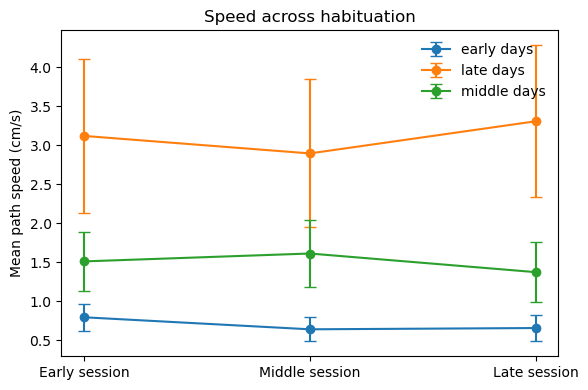

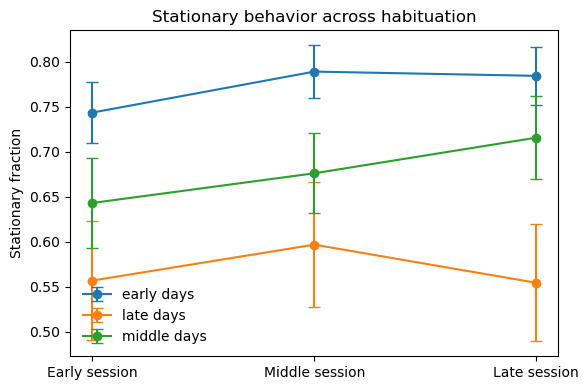

In [172]:
import matplotlib.pyplot as plt

def plot_hab_summary(summary_df, y_col, sem_col, ylabel, title):
    fig, ax = plt.subplots(figsize=(6, 4))

    x_order = ["early", "middle", "late"]
    x = np.arange(len(x_order))

    for day_bin, sub in summary_df.groupby("phase_day_bin", observed=False):
        sub = sub.set_index("session_time_bin").loc[x_order].reset_index()

        ax.errorbar(
            x,
            sub[y_col],
            yerr=sub[sem_col],
            marker="o",
            capsize=4,
            label=f"{day_bin} days"
        )

    ax.set_xticks(x)
    ax.set_xticklabels(["Early session", "Middle session", "Late session"])
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(frameon=False)
    plt.tight_layout()
    plt.show()


speed_summary = (
    hab_led_rm_df
    .groupby(["phase_day_bin", "session_time_bin"], observed=False)
    .agg(
        mean_speed=("mean_speed_path_cms", "mean"),
        sem_speed=("mean_speed_path_cms", lambda x: x.std(ddof=1) / np.sqrt(len(x))),
        n=("animal", "nunique"),
    )
    .reset_index()
)

stationary_summary = (
    hab_led_rm_df
    .groupby(["phase_day_bin", "session_time_bin"], observed=False)
    .agg(
        mean_stationary=("frac_stationary", "mean"),
        sem_stationary=("frac_stationary", lambda x: x.std(ddof=1) / np.sqrt(len(x))),
        n=("animal", "nunique"),
    )
    .reset_index()
)

plot_hab_summary(
    speed_summary,
    y_col="mean_speed",
    sem_col="sem_speed",
    ylabel="Mean path speed (cm/s)",
    title="Speed across habituation"
)

plot_hab_summary(
    stationary_summary,
    y_col="mean_stationary",
    sem_col="sem_stationary",
    ylabel="Stationary fraction",
    title="Stationary behavior across habituation"
)